# Building a Customer Feedback Analysis System Using NLP

In [15]:
import pandas as pd
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score


data = [
    ("Payment keeps failing", "negative", ["payment"]),
    ("The application is very slow", "negative", ["performance"]),
    ("I love the new dashboard", "positive", ["ui"]),
    ("Support solved my issue quickly", "positive", ["support"]),
    ("Login OTP is not arriving", "negative", ["login"]),
    ("The app is slow and payment fails", "negative", ["performance", "payment"]),
    ("Excellent customer support", "positive", ["support"]),
    ("The service is okay", "neutral", ["general"]),
    ("The latest update is good but payment is failing frequently",
     "negative", ["payment", "performance"]),
    ("The support team solved my issue very quickly",
     "positive", ["support"]),
    ("App is extremely slow", "negative", ["performance"]),
    ("The application is okay", "neutral", ["general"]),
    ("Payment gateway crashed during checkout", "negative", ["payment"]),
    ("Login page keeps timing out", "negative", ["login"]),
    ("The new UI looks beautiful", "positive", ["ui"]),
    ("Support team was rude and unhelpful", "negative", ["support"]),
    ("App freezes every time I open it", "negative", ["performance"]),
    ("Payment succeeded but receipt never arrived", "negative", ["payment"]),
    ("OTP arrives fine now, good fix", "positive", ["login"]),
    ("Dashboard redesign is confusing", "negative", ["ui"]),
    ("Customer care resolved my ticket fast", "positive", ["support"]),
    ("Nothing to complain about, works fine", "neutral", ["general"]),
    ("Slow app and OTP delay both happened today",
     "negative", ["performance", "login"]),
    ("Great job on the payment refund process",
     "positive", ["payment"])
]


df = pd.DataFrame(
    data,
    columns=["feedback", "sentiment", "categories"]
)



df.head()

,feedback,sentiment,categories
0,Payment keeps failing,negative,[payment]
1,The application is very slow,negative,[performance]
2,I love the new dashboard,positive,[ui]
3,Support solved my issue quickly,positive,[support]
4,Login OTP is not arriving,negative,[login]


### Text Cleaning

In [2]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)

    return text


df["clean_feedback"] = df["feedback"].apply(clean_text)

df[["feedback", "clean_feedback"]]

,feedback,clean_feedback
0,Payment keeps failing,payment keeps failing
1,The application is very slow,the application is very slow
2,I love the new dashboard,i love the new dashboard
3,Support solved my issue quickly,support solved my issue quickly
4,Login OTP is not arriving,login otp is not arriving
5,The app is slow and payment fails,the app is slow and payment fails
6,Excellent customer support,excellent customer support
7,The service is okay,the service is okay
8,The latest update is good but payment is faili...,the latest update is good but payment is faili...
9,The support team solved my issue very quickly,the support team solved my issue very quickly


### Sentiment Model

In [3]:
X = df["clean_feedback"]
y_sentiment = df["sentiment"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_sentiment
)


sentiment_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            stop_words="english"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])


sentiment_model.fit(
    X_train,
    y_train
)


y_pred = sentiment_model.predict(X_test)


print("Sentiment Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Sentiment Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

    negative       0.75      1.00      0.86         3
    positive       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



### Multi-Label Categories

In [4]:
mlb = MultiLabelBinarizer()

y_categories = mlb.fit_transform(
    df["categories"]
)

print("Category Classes:")
print(mlb.classes_)

print("\nEncoded Categories:")
print(y_categories)

Category Classes:
['general' 'login' 'payment' 'performance' 'support' 'ui']

Encoded Categories:
[[0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 1 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 1 0]
 [1 0 0 0 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 1 0 0]
 [1 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [0 0 0 1 0 0]
 [0 0 1 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 1]
 [0 0 0 0 1 0]
 [1 0 0 0 0 0]
 [0 1 0 1 0 0]
 [0 0 1 0 0 0]]


### Category Model

In [5]:
X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X,
    y_categories,
    test_size=0.2,
    random_state=42
)


category_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english"
)


X_train_vec = category_vectorizer.fit_transform(
    X_cat_train
)

X_test_vec = category_vectorizer.transform(
    X_cat_test
)


category_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000
    )
)


category_model.fit(
    X_train_vec,
    y_cat_train
)


y_cat_pred = category_model.predict(
    X_test_vec
)


print("Category Classes:")
print(mlb.classes_)

print("\nMicro F1:",
      f1_score(
          y_cat_test,
          y_cat_pred,
          average="micro",
          zero_division=0
      ))

print("Macro F1:",
      f1_score(
          y_cat_test,
          y_cat_pred,
          average="macro",
          zero_division=0
      ))

Category Classes:
['general' 'login' 'payment' 'performance' 'support' 'ui']

Micro F1: 0.0
Macro F1: 0.0


### Full Category Model

In [6]:
cat_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english"
)


X_full_cat = cat_vectorizer.fit_transform(
    df["clean_feedback"]
)


category_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000
    )
)


category_model.fit(
    X_full_cat,
    y_categories
)

,estimator,LogisticRegre...max_iter=1000)
,n_jobs,None
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None


### New Customer Feedback

In [7]:
new_feedback = [
    "The application is very slow and payment keeps failing."
]


clean_new_feedback = [
    clean_text(text)
    for text in new_feedback
]


print("Original Feedback:")
print(new_feedback[0])

print("\nCleaned Feedback:")
print(clean_new_feedback[0])

Original Feedback:
The application is very slow and payment keeps failing.

Cleaned Feedback:
the application is very slow and payment keeps failing.


### Predict Sentiment

In [8]:
predicted_sentiment = sentiment_model.predict(
    clean_new_feedback
)

print("Predicted Sentiment:")
print(predicted_sentiment[0])

Predicted Sentiment:
negative


### Predict Categories

In [9]:
new_category_vector = cat_vectorizer.transform(
    clean_new_feedback
)


predicted_category_values = category_model.predict(
    new_category_vector
)


predicted_categories = mlb.inverse_transform(
    predicted_category_values
)


print("Predicted Categories:")
print(predicted_categories[0])

Predicted Categories:
()


### Final Output

In [10]:
print("\n===================================")
print("     CUSTOMER FEEDBACK ANALYSIS")
print("===================================")

print("\nCustomer Feedback:")
print(new_feedback[0])

print("\nSentiment:")
print(predicted_sentiment[0])

print("\nCategories:")

for category in predicted_categories[0]:
    print("-", category)


     CUSTOMER FEEDBACK ANALYSIS

Customer Feedback:
The application is very slow and payment keeps failing.

Sentiment:
negative

Categories:


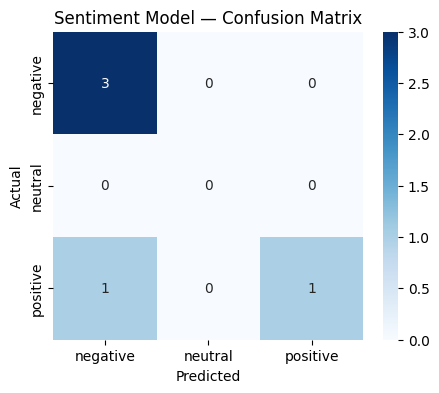

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred, labels=sentiment_model.classes_)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sentiment_model.classes_,
    yticklabels=sentiment_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Model — Confusion Matrix")
plt.show()